In [1]:
#import packages
import numpy as np
from scipy.optimize import minimize
import weighted_maxcut_qaoa as qaoa #this is a .py file with my qaoa code
from qiskit.visualization import plot_histogram
import networkx as nx
from matplotlib import pyplot as plt
plt.style.use('seaborn')

# Weighted Max-Cut

#### Application: Clustering within Autonomous Sensor Data

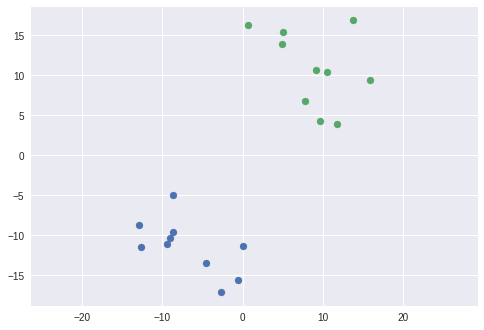

In [2]:
# set up two random distributions with n_points total points and plot
n_points = 20
n1 = n_points//2
n2 = n_points//2
set1  = np.random.normal(-10, 5, (2, n1))
set2 = np.random.normal(10, 5, (2, n2))
plt.scatter(set1[0, :], set1[1, :])
plt.scatter(set2[0, :], set2[1, :])
plt.axis('equal')
plt.show()     

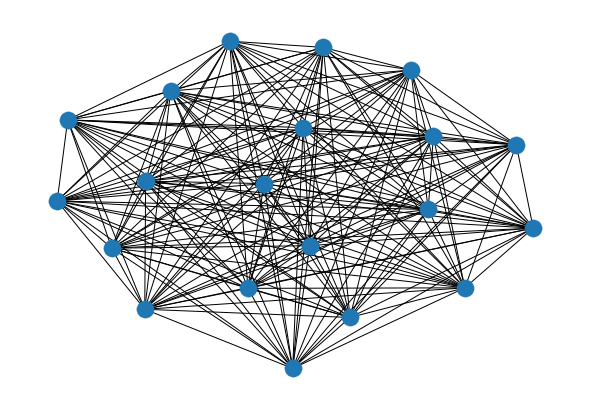

In [3]:
# create a dictionary mapping points to nodes
combined_set = np.hstack((set1, set2))
nodes_points = dict()
counter = 0
for column in range(combined_set.shape[1]):
    nodes_points[counter] = combined_set[:, column]
    counter += 1
nodes = nodes_points.keys()

# now set up edges with weights corresponding to distances between nodes/points
G = nx.Graph()
for node1 in nodes:
    point1 = nodes_points[node1]
    for node2 in nodes:
        if node2 == node1:
            continue
        point2 = nodes_points[node2]
        weight = round(np.linalg.norm(point1 - point2), 4)
        G.add_edge(node1, node2, weight=weight)

# draw the graph (note that weight is not reflected here as of now, gets messy)
nx.draw(G)

     fun: -1163.294304296875
   maxcv: 1.5075785410433418e-19
 message: 'Optimization terminated successfully.'
    nfev: 235
  status: 1
 success: True
       x: array([ 2.71189160e-02,  9.65981755e-01,  2.37224049e-01,  1.45096772e-06,
        9.89332978e-01,  6.59385350e-03,  5.20655206e-03,  5.83888126e-03,
        1.94695475e-02,  4.16182935e-04,  8.21601167e-03, -3.35743665e-23,
       -1.50757854e-19,  8.21281078e-03,  4.24353404e-03,  9.99235143e-01,
        6.22105498e-03,  1.06093455e+00, -1.12173210e-19,  3.93411602e-02])

Optimal Bitstring: 11111111110000000000


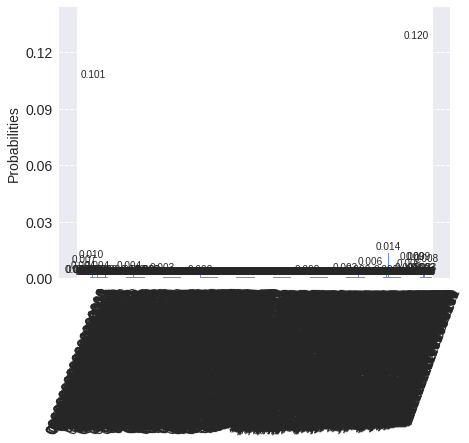

In [4]:
# get the expectation function from qaoa.py
n_layers = n_points//2 #number of layers (scale it up linearly with n_points)
expectation = qaoa.get_expectation(G, n_layers, shots=2**8)

# minimize the expectation by running the circuit
req = {'type':'ineq', 'fun':lambda x:x} #this forces the params to be nonnegative
initial_params = 0.01*np.random.rand(2*n_layers)/n_points
sol = minimize(expectation, initial_params, method='COBYLA', constraints=req)
print(sol)

# get the optimal bitstring we found and print it
counts = expectation(sol.x, return_counts=True)[1]
opt_bitstring = list(counts.keys())[np.argmax(list(counts.values()))]
print('\nOptimal Bitstring: ' + opt_bitstring)

# plot a histogram of the bitstring counts using our optimized parameters
plot_histogram(counts)

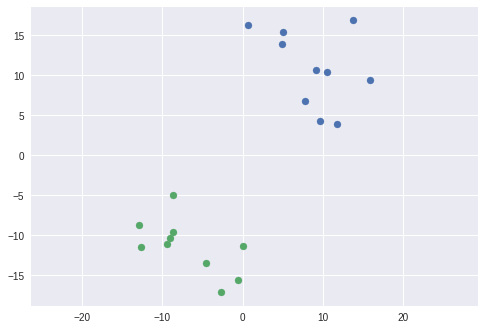

In [5]:
# convert the result back to points separated by the cut we found above
cluster0, cluster1 = [], []
counter = 0
for char in opt_bitstring:
    if int(char) == 0:
        cluster0.append(nodes_points[counter])
    else:
        cluster1.append(nodes_points[counter])
    counter += 1

# plot our points/clusters
cluster0 = np.vstack((cluster0)).T
plt.scatter(cluster0[0, :], cluster0[1, :])
cluster1 = np.vstack((cluster1)).T
plt.scatter(cluster1[0, :], cluster1[1, :])
plt.axis('equal')
plt.show()